In [30]:
import pandas as pd
df = pd.read_csv((r'C:\Users\axel_\Documents\conda\random-games\playerStats\csv\arsenal-vs-atletico-madrid-v1.csv'))
df.head()

,name,id,optaId,teamId,teamName,isGoalkeeper,stats,shirtNumber,positionId,usualPosition,...,gk_saves,gk_goals_conceded,gk_xGOT_faced,gk_goals_prevented,gk_diving_save,gk_saves_inside_box,gk_acted_as_sweeper,gk_punches,gk_throws,gk_high_claim
0,Jan Oblak,177126,81352,9906,Atlético de Madrid,True,"[{'title': 'Top stats', 'key': 'top_stats', 's...",13,11.0,0,...,1.0,1.0,0.7,-0.3,0.0,0.0,2.0,0.0,3.0,0.0
1,Antoine Griezmann,184138,76650,9906,Atlético de Madrid,False,"[{'title': 'Top stats', 'key': 'top_stats', 's...",7,104.0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Koke,184533,77390,9906,Atlético de Madrid,False,"[{'title': 'Top stats', 'key': 'top_stats', 's...",6,74.0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Christian Nørgaard,266520,128295,9825,Arsenal,False,[],16,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kepa Arrizabalaga,317564,109745,9825,Arsenal,True,[],13,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.columns

Index(['name', 'id', 'optaId', 'teamId', 'teamName', 'isGoalkeeper', 'stats',
       'shirtNumber', 'positionId', 'usualPosition', 'matchId', 'matchRound',
       'homeTeamName', 'homeTeamid', 'awayTeamName', 'awayTeamid', 'matchDate',
       'home_goals', 'away_goals', 'FotMob_rating', 'Minutes_played', 'Goals',
       'Assists', 'Total_shots', 'Accurate_passes_value',
       'Accurate_passes_total', 'Chances_created', 'Expected_assists_xA',
       'xG_plus_xA', 'Fantasy_points', 'Defensive_actions', 'touches',
       'touches_opp_box', 'passes_into_final_third', 'accurate_crosses_value',
       'accurate_crosses_total', 'long_balls_accurate_value',
       'long_balls_accurate_total', 'dispossessed', 'tackles_succeeded_value',
       'tackles_succeeded_total', 'shot_blocks', 'clearances',
       'headed_clearance', 'interceptions', 'recoveries', 'dribbled_past',
       'duel_won', 'duel_lost', 'ground_duels_won_value',
       'ground_duels_won_total', 'aerials_won_value', 'aerials_won

In [21]:
df[['name', 'Accurate_passes_value', 'Accurate_passes_total', 'Chances_created', 'touches', 'Goals', 'shots_off_target', 'shots_on_target', 'shot_accuracy', 'Total_shots']].head()

,name,Accurate_passes_value,Accurate_passes_total,Chances_created,touches,Goals,shots_off_target,shots_on_target,shot_accuracy,Total_shots
0,Jan Oblak,23.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Antoine Griezmann,39.0,48.0,2.0,62.0,0.0,1.0,0.0,0.0,NaN
2,Koke,58.0,70.0,1.0,81.0,0.0,NaN,NaN,NaN,NaN
3,Christian Nørgaard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kepa Arrizabalaga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# df with passes
w_df = df[['name', 'Accurate_passes_value', 'Accurate_passes_total']]
w_df.head()

,name,Accurate_passes_value,Accurate_passes_total
0,Jan Oblak,23.0,39.0
1,Antoine Griezmann,39.0,48.0
2,Koke,58.0,70.0
3,Christian Nørgaard,NaN,NaN
4,Kepa Arrizabalaga,NaN,NaN


In [32]:
# drop NA
w_df = w_df.dropna(subset=['Accurate_passes_value'])
w_df

,name,Accurate_passes_value,Accurate_passes_total
0,Jan Oblak,23.0,39.0
1,Antoine Griezmann,39.0,48.0
2,Koke,58.0,70.0
5,Leandro Trossard,12.0,12.0
9,Martin Ødegaard,32.0,35.0
10,David Raya,19.0,27.0
11,Gabriel Jesus,6.0,8.0
12,Marcos Llorente,30.0,32.0
13,Robin Le Normand,31.0,34.0
14,Declan Rice,83.0,89.0


In [33]:
w_df['accurate_passes'] = w_df['Accurate_passes_total'] - w_df['Accurate_passes_value']
w_df.head()

,name,Accurate_passes_value,Accurate_passes_total,accurate_passes
0,Jan Oblak,23.0,39.0,16.0
1,Antoine Griezmann,39.0,48.0,9.0
2,Koke,58.0,70.0,12.0
5,Leandro Trossard,12.0,12.0,0.0
9,Martin Ødegaard,32.0,35.0,3.0


In [34]:
# df with passes
w_df = w_df[['name', 'Accurate_passes_total', 'accurate_passes']]
w_df.head()

,name,Accurate_passes_total,accurate_passes
0,Jan Oblak,39.0,16.0
1,Antoine Griezmann,48.0,9.0
2,Koke,70.0,12.0
5,Leandro Trossard,12.0,0.0
9,Martin Ødegaard,35.0,3.0


In [35]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from pywaffle import Waffle

In [36]:
# sort data by accurate passes value
w_df = w_df.sort_values(by=['Accurate_passes_total'], ascending=False)
w_df.head()

,name,Accurate_passes_total,accurate_passes
14,Declan Rice,89.0,6.0
2,Koke,70.0,12.0
18,Dávid Hancko,67.0,9.0
24,William Saliba,62.0,3.0
28,Martín Zubimendi,51.0,5.0


In [37]:
# transpose the df
w_df = w_df.T
w_df.head()

,14,2,18,24,28,33,20,1,29,0,...,27,21,34,5,25,15,11,22,17,37
name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0
accurate_passes,6.0,12.0,9.0,3.0,5.0,7.0,4.0,9.0,6.0,16.0,...,2.0,3.0,3.0,0.0,1.0,3.0,2.0,2.0,1.0,0.0


In [38]:
# remove indexs at the top
w_df.columns = w_df.iloc[0]
w_df.head()

name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0
accurate_passes,6.0,12.0,9.0,3.0,5.0,7.0,4.0,9.0,6.0,16.0,...,2.0,3.0,3.0,0.0,1.0,3.0,2.0,2.0,1.0,0.0


In [39]:
# drop the player names rows
w_df = w_df.drop('name')
w_df.head()

name,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0
accurate_passes,6.0,12.0,9.0,3.0,5.0,7.0,4.0,9.0,6.0,16.0,...,2.0,3.0,3.0,0.0,1.0,3.0,2.0,2.0,1.0,0.0


In [40]:
# create list with the columns
my_list = w_df.columns.values.tolist()
my_list

['Declan Rice',
 'Koke',
 'Dávid Hancko',
 'William Saliba',
 'Martín Zubimendi',
 'Johnny Cardoso',
 'Gabriel',
 'Antoine Griezmann',
 'Matteo Ruggeri',
 'Jan Oblak',
 'Marc Pubill',
 'Piero Hincapié',
 'Martin Ødegaard',
 'Robin Le Normand',
 'Marcos Llorente',
 'Ademola Lookman',
 'Julián Álvarez',
 'David Raya',
 'Ben White',
 'Noni Madueke',
 'Gabriel Martinelli',
 'Eberechi Eze',
 'Giuliano Simeone',
 'Leandro Trossard',
 'Bukayo Saka',
 'Viktor Gyökeres',
 'Gabriel Jesus',
 'Álex Baena',
 'Nahuel Molina',
 'Cristhian Mosquera']

In [41]:
# new df with my_list for the columns
w_df = pd.DataFrame(w_df, columns=my_list)
w_df.head()

,Declan Rice,Koke,Dávid Hancko,William Saliba,Martín Zubimendi,Johnny Cardoso,Gabriel,Antoine Griezmann,Matteo Ruggeri,Jan Oblak,...,Gabriel Martinelli,Eberechi Eze,Giuliano Simeone,Leandro Trossard,Bukayo Saka,Viktor Gyökeres,Gabriel Jesus,Álex Baena,Nahuel Molina,Cristhian Mosquera
Accurate_passes_total,89.0,70.0,67.0,62.0,51.0,49.0,49.0,48.0,45.0,39.0,...,21.0,20.0,13.0,12.0,11.0,9.0,8.0,6.0,3.0,3.0
accurate_passes,6.0,12.0,9.0,3.0,5.0,7.0,4.0,9.0,6.0,16.0,...,2.0,3.0,3.0,0.0,1.0,3.0,2.0,2.0,1.0,0.0


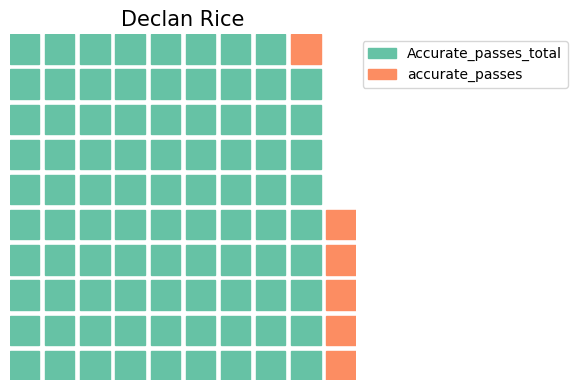

In [42]:
fig = plt.figure(
    FigureClass=Waffle,
    values=w_df.iloc[:,0],
    labels=list(w_df.index),
    rows=10,
    title={
        'label':my_list[0],
        'fontdict': {
            'fontsize': 15
        }
    },
    figsize=(8,4),
    legend={
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1)
    },
)

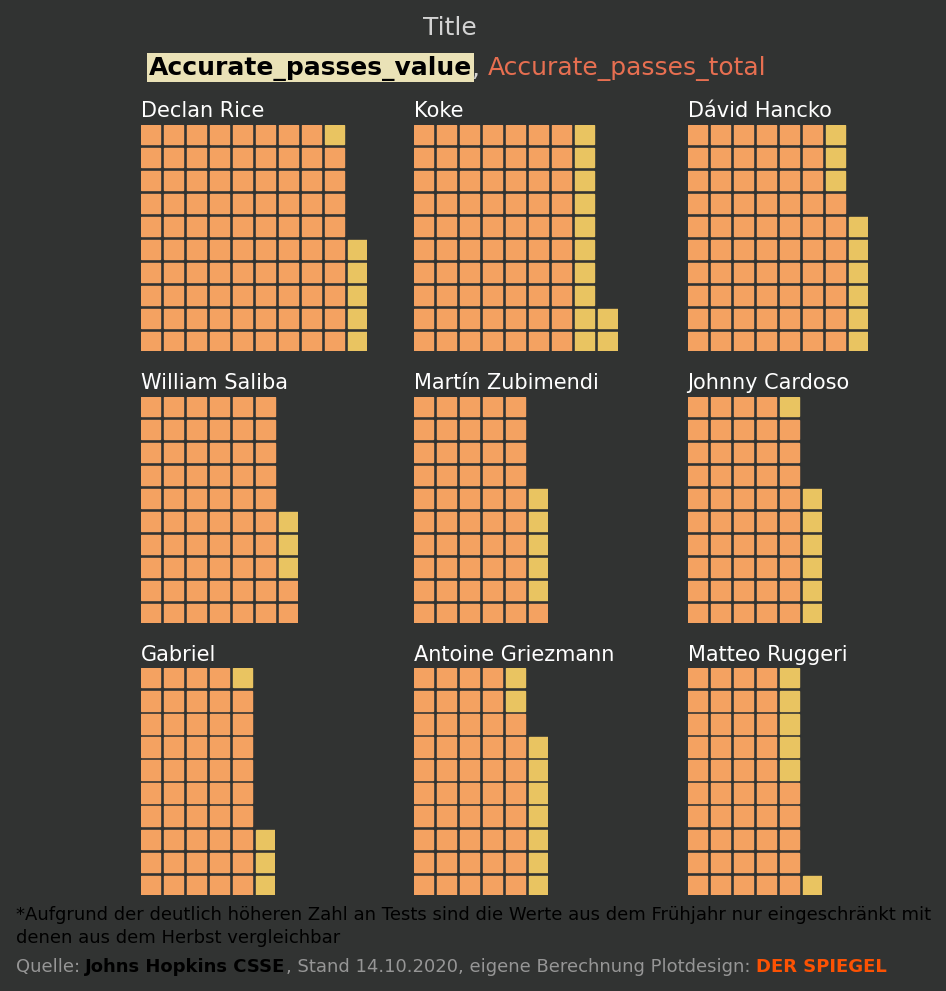

In [43]:
from highlight_text import fig_text

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    figsize=(10,10),
    tight=False,
    plots={ #331 3x3 1 is the first plot
        (3,3,1):{
            'values':w_df.iloc[:,0],
            'title':{
                'label':my_list[0],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,2):{
            'values':w_df.iloc[:,1],
            'title':{
                'label':my_list[1],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,3):{
            'values':w_df.iloc[:,2],
            'title':{
                'label':my_list[2],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,4):{
            'values':w_df.iloc[:,3],
            'title':{
                'label':my_list[3],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,5):{
            'values':w_df.iloc[:,4],
            'title':{
                'label':my_list[4],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,6):{
            'values':w_df.iloc[:,5],
            'title':{
                'label':my_list[5],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,7):{
            'values':w_df.iloc[:,6],
            'title':{
                'label':my_list[6],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,8):{
            'values':w_df.iloc[:,7],
            'title':{
                'label':my_list[7],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        },
        (3,3,9):{
            'values':w_df.iloc[:,8],
            'title':{
                'label':my_list[8],
                'color':'white',
                'loc':'left',
                'fontsize': 15
            }
        }
    },
    colors = ['#f4a261', '#e9c461']
)

bbox_pad = 1.5
bboxprops = {'linewidth': 0, 'pad': bbox_pad}

fig_text(
    s='Title \n <Accurate_passes_value>, <Accurate_passes_total>',
    x=0.125,
    y=.99,
    fontsize=18,
    textalign='center',
    vsep=12,
    color='lightgrey',
    highlight_textprops=[
        {'color': 'black', 'weight': 'bold', 'bbox': {'facecolor':'#eae2b7', **bboxprops}},
        # {"color": '#eae2b7'},
        {"color": '#e76f51'},
    ]
)
fig_text(
    s='<*Aufgrund der deutlich höheren Zahl an Tests sind die Werte aus dem Frühjahr nur eingeschränkt mit>\n' '<denen aus dem Herbst vergleichbar>\n\n' 'Quelle: <Johns Hopkins CSSE>, Stand 14.10.2020, eigene Berechnung Plotdesign: <DER SPIEGEL>',
    highlight_textprops=[
        {'color': 'k', 'weight': 'regular'},
        {'color': 'k', 'weight': 'regular'},
        {'color': 'k', 'weight': 'bold'},
        {'color': '#fc5203', 'weight': 'bold'}
    ],
    color='#969696',
    x=0, y=0.1,
    fontsize=13
)

fig.patch.set_facecolor('#313332')

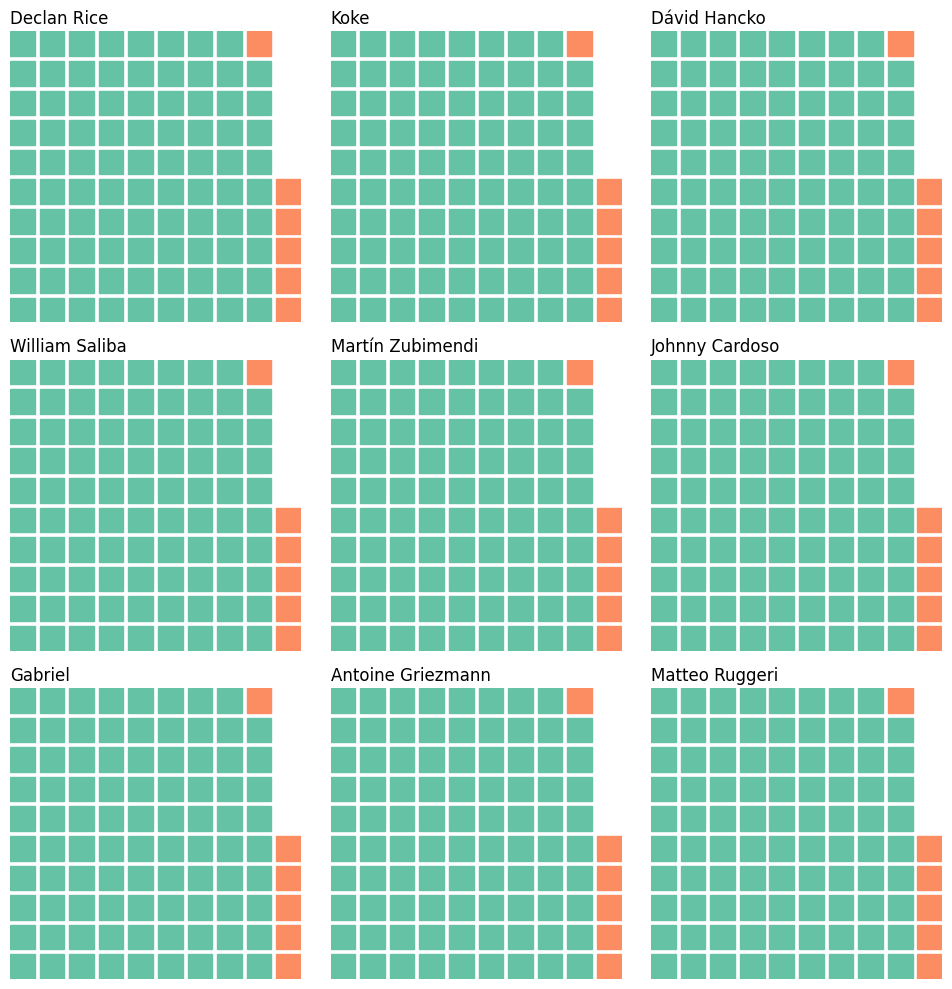

In [44]:
plots = {}

for i in range(9):
    plots[(3,3,i+1)] = {
        'values': w_df.iloc[:,0],
        'title': {
            'label': my_list[i],
            'color': 'black',
            'loc': 'left'
        }
    }

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    figsize=(10,10),
    plots=plots
)